### Models of audiovisual decisions and how they change during brain manipulations

This is  brief tutorial to show how to use this package by walking through how we fit audiovisal decisions and the behaviour has been described [here](https://www.biorxiv.org/content/10.64898/2026.06.05.730072v1). The original task was developed by [Coen, Sit, et al., 2023](https://www.sciencedirect.com/science/article/pii/S0896627323003811?via%3Dihub).  The dataset contains brain inactivations from both papers (i.e. SC and cortical areas). Columns are: 

| Variable | Description |
| :--- | :--- |
| **visDiff** | Visual Evidence Difference: The signed difference between right and left visual contrasts ($visR - visL$). |
| **audDiff** | Auditory Evidence Difference: The signed difference between right and left auditory evidence ($audR - audL$). |
| **visL** | Visual Contrast Left: The intensity/contrast of the visual stimulus on the left (0 to 1). |
| **visR** | Visual Contrast Right: The intensity/contrast of the visual stimulus on the right (0 to 1). |
| **audL** | Auditory Intensity Left: The azimuth of auditory stimulus on the left normalised between 0 and 90 deg. |
| **audR** | Auditory Intensity Right: The azimuth of auditory stimulus on the right normalised between 0 and 90 deg. |
| **RT** | Reaction Time: The time from stimulus onset to the subject's response (seconds). |
| **choice_** | Subject Choice: The outcome of the trial (e.g., Left, Right, or NoGo). |
| **inactivation_type** | Brain Region Inactivated encoded as strings: {area}_{hemisphere}. |
| **opto** | Optogenetic Flag: Indicates if optogenetic stimulation was active (1) or inactive (0). |
| **subject** |The unique identifier for the mouse. |
| **session_id** | Session Identifier: The unique ID for the specific experimental session (day). |

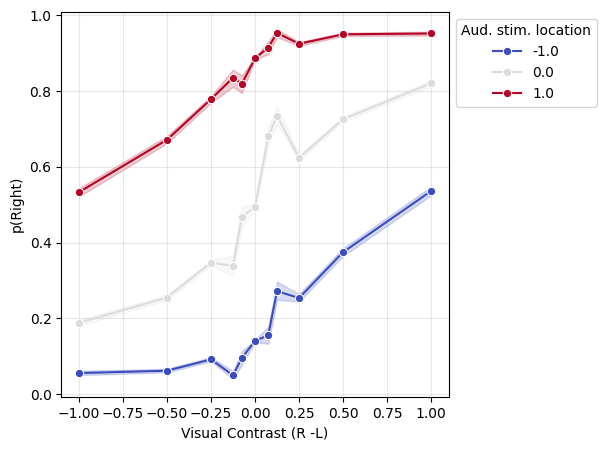

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('audiovisual_behaviour.csv')

# Clean data: Filter for Go trials and map choice to binary
df_ctrl = df[(df['opto'] == 0) & (df['choice_'].isin(['Left', 'Right']))].copy()
df_ctrl['choice_val'] = (df_ctrl['choice_'] == 'Right').astype(int)

# Plotting with Seaborn
plt.figure(figsize=(5, 5))
sns.lineplot(
    data=df_ctrl, 
    x='visDiff', 
    y='choice_val', 
    hue='audDiff', 
    marker='o', 
    palette='coolwarm'
)

plt.xlabel('Visual Contrast (R -L)')
plt.ylabel('p(Right)')
plt.legend(title='Aud. stim. location', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)
plt.show()

Note that this way of looking at the data is rather noisy because we are just averaging across all mice, not taking into account e.g. how many trials from each mouse contributes to the average. Let's look instead at just one animal and fit the audiovisual Logistic model, where: 

$$
\log \left( \frac{P(\text{Right})}{P(\text{Left})} \right) = v_{L} V_{L}^{\gamma} + v_{R} V_{R}^{\gamma} + a_{L} A_{L} + a_{R} A_{R} + \text{bias}
$$


for this the model class is implemented `av_models_opto\av_split`

Text(0, 0.5, 'p(Right)')

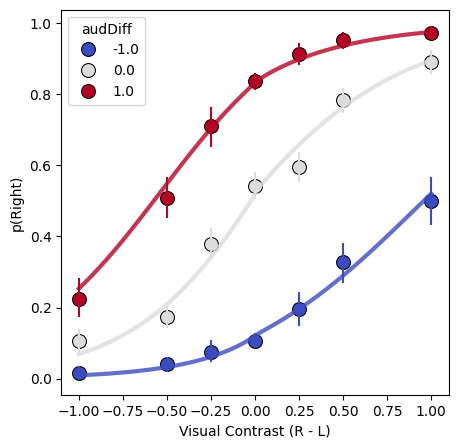

In [2]:
df_AV036 = df_ctrl[df_ctrl['subject'] == 'AV036']

# import av logistic model
from NeuroLogit.src.models.av_models_opto import av_split


X = df_AV036[['visR', 'audR', 'visL', 'audL']]
y = df_AV036['choice_'].map({'Left': 0, 'Right': 1}).values
m = av_split()
m.fit(X, y)



# plot
import matplotlib.cm as cm
import matplotlib.colors as mcolors

all_aud_diffs = df_AV036['audDiff'].unique()
norm = mcolors.Normalize(vmin=min(all_aud_diffs), vmax=max(all_aud_diffs))
cmap =  plt.colormaps['coolwarm'] 

fig, ax = plt.subplots(figsize=(5, 5))

# 2. Plot the behavioral points
# We use the same 'coolwarm' palette
sns.lineplot(
    data=df_AV036,
    x='visDiff', 
    y='choice_val', 
    hue='audDiff', 
    marker='o', 
    palette='coolwarm',
    linestyle='none',
    err_style='bars',
    markeredgecolor='black',
    markersize=10,
    ax=ax
)

# 3. Plot the model predictions
pred_matrices = m.pseudo # Assuming this is a list of DataFrames

for pred_matrix in pred_matrices:
    # Identify which audDiff this specific matrix is for
    current_aud_diff = (pred_matrix['audR'] - pred_matrix['audL']).iloc[0]  # Assuming audDiff is constant within this matrix
    
    # Get the EXACT color from the colormap based on the value
    line_color = cmap(norm(current_aud_diff))
    
    # Predict and plot
    pred_ = m.predict_proba(pred_matrix)
    ax.plot(
        pred_matrix['visR'] - pred_matrix['visL'], 
        pred_, 
        color=line_color, # Match!
        alpha=0.8, 
        lw=3
    )

# Clean up legend (to avoid double entries)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(all_aud_diffs)], labels[:len(all_aud_diffs)], title='audDiff')
ax.set_xlabel('Visual Contrast (R - L)')
ax.set_ylabel('p(Right)')


It is often useful to look at the log-odds instead of the fraction of Rightward choices. For convenience of interpreation we also often gamma-transform the x-axis so the behaviour becomes lines. 

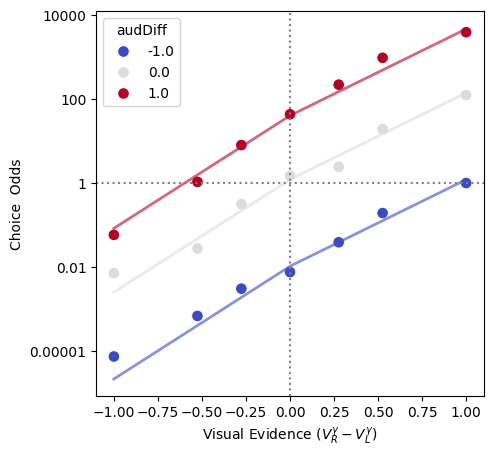

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.special import logit

# 1. Prepare the data (Group and Transform)
gamma = m.params['gamma']
df_plot = df_AV036.groupby(['visL', 'visR', 'audDiff'])['choice_val'].mean().reset_index()

# Transform X (Visual) and Y (Choice)
df_plot['x_trans'] = df_plot['visR']**gamma - df_plot['visL']**gamma
df_plot['y_logit'] = logit(df_plot['choice_val'].clip(0.01, 0.99)) # Clip avoids infinity

# 2. Plot Dots
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df_plot, x='x_trans', y='y_logit', hue='audDiff', palette='coolwarm', s=70)

# 3. Plot Model Lines
for p_matrix in m.pseudo:
    p_matrix['audDiff'] = p_matrix['audR'] - p_matrix['audL']  # Ensure audDiff is present
    x_line = p_matrix['visR']**gamma - p_matrix['visL']**gamma
    y_line = logit(m.predict_proba(p_matrix)) # or use m.predict_log_odds if you have it
    
    # Get the color from the scatter palette (match by audDiff)
    color = sns.color_palette("coolwarm", as_cmap=True)(
        (p_matrix['audDiff'].iloc[0] - df_plot['audDiff'].min()) / 
        (df_plot['audDiff'].max() - df_plot['audDiff'].min())
    )
    plt.plot(x_line, y_line, color=color, lw=2, alpha=0.6)

plt.axhline(0, color='grey', ls=':')
plt.axvline(0, color='grey', ls=':')
plt.xlabel('Visual Evidence ($V_R^\gamma - V_L^\gamma$)')
plt.ylabel('Choice  Odds')
plt.yticks([-4, -2, 0, 2, 4], ['0.00001', '0.01', '1', '100', '10000']) # Corresponding Odds (Log is on a 10 base)
plt.show()

We have discovered that often mice don't make a choice, especially if you leave the response window quite short reflecting perhaps that to make any choice at all is evergentically costy. We can also model such decisions using Logistic models. In particular I am using the 3-class Logistic model with NoGo as a reference class. This is  different from the scikit-learn multi-out logistic models,which a weight vector for every class, including the reference class, resulting in K weight vectors for K classes. In contrast, fitting with a reference class only requires K-1 vectors. While the symmetric model is useful for deep learning, it is over-parameterised, which limits its utility when you want to interpret the actual parameters. 

Let's now fit the `MultinomialLogit` model using NoGos as the reference class. For this, there are several audiovisual models implemented in `av_models_multi` that you may test as you wish. In [my paper](https://www.biorxiv.org/content/10.64898/2026.06.05.730072v2.full.pdf) I use `av_multi_symmetric_audio`. Let's fit this model on an example mouse and look at the parameters. 


In [16]:
from NeuroLogit.src.models.av_models_multi import av_multi_symmetric_audio

df_withNoGo_AV036 = df[(df['opto'] == 0) &
                       (df['subject'] == 'AV036')].copy()
choice_map = {'NoGo': 0, 'Left': 1, 'Right': 2}

choices = df_withNoGo_AV036['choice_'].map(choice_map).values
model_multi = av_multi_symmetric_audio()
model_multi.fit(df_withNoGo_AV036[['visR', 'audR', 'visL', 'audL']], choices)
model_multi.get_params()

{'audR': 0.7489746681292632,
 'audL': 1.0425239251123566,
 'visR': 1.9513767415737073,
 'visL': 2.518945735327473,
 'gamma': 0.9139718504017325,
 'biasL': 0.6901423745711913,
 'biasR': 0.7689964537720858}

Now let's plot the results as the ratio of various odds. For this I am making two tiny functions that calculate the odds from the data (`choice_odds`) and that plot it together with the prediciton (`plot_3odds`). Note that for the counts to not be infinity I add one of to each class (hence +1). I also have a helper class that generates the inputs for the model to plot the countinuous prediciton at all stimulus values ('av_pseudoplotter').

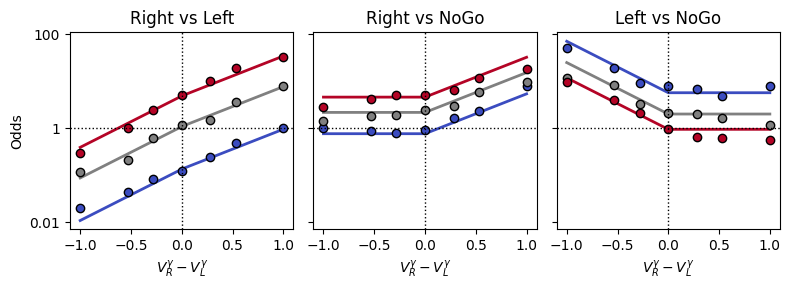

In [26]:
import numpy as np
from NeuroLogit.src.models.av_models_opto import av_pseudoPlotter
 
def choice_odds(d, gamma):
    '''Log odds of each choice pair per stimulus condition (+1 fake trial each).'''
    counts = (d.groupby(['visL', 'visR', 'audL', 'audR'])['choice_']
                .value_counts().unstack(fill_value=0)
                .reindex(columns=['NoGo', 'Left', 'Right'], fill_value=0) + 1).reset_index()
    counts['x'] = counts.visR**gamma - counts.visL**gamma
    counts['audDiff'] = counts.audR - counts.audL
    counts['R_vs_L'] = np.log(counts.Right / counts.Left)
    counts['R_vs_NoGo'] = np.log(counts.Right / counts.NoGo)
    counts['L_vs_NoGo'] = np.log(counts.Left / counts.NoGo)
    return counts


def plot_3odds(model, d, axs, opto=None, ls='-', show_data=True):
    gamma = model.params['gamma']
    colors = {-1: cmap(0.0), 0: 'grey', 1: cmap(1.0)}

    # model predictions (lines)
    for pm in av_pseudoPlotter().pseudo:
        if opto is not None:
            pm['bias_opto'] = opto
        aud = float((pm.audR - pm.audL).iloc[0])
        zL, zR = model.predict_log_proba(pm)
        x = pm.visR**gamma - pm.visL**gamma
        for ax, z in zip(axs, [zR - zL, zR, zL]):
            ax.plot(x, z, color=colors[aud], lw=2, ls=ls)

    # data (dots)
    if show_data:
        for aud, od in choice_odds(d, gamma).groupby('audDiff'):
            for ax, col in zip(axs, ['R_vs_L', 'R_vs_NoGo', 'L_vs_NoGo']):
                ax.plot(od.x, od[col], color=colors[aud], marker='o', ls='none',
                        markeredgecolor='k', markersize=6)

    for ax, title in zip(axs, ['Right vs Left', 'Right vs NoGo', 'Left vs NoGo']):
        ax.axhline(0, color='k', ls=':', lw=1)
        ax.axvline(0, color='k', ls=':', lw=1)
        ax.set_title(title)
        ax.set_xlabel(r'$V_R^\gamma - V_L^\gamma$')
    axs[0].set_yticks([-np.log(100), 0, np.log(100)], ['0.01', '1', '100'])
    axs[0].set_ylabel('Odds')

    
    # plot
fig, axs = plt.subplots(1, 3, figsize=(8, 3), sharex=True, sharey=True)
plot_3odds(model_multi, df_withNoGo_AV036, axs)
plt.tight_layout()
plt.show()

Finally we can also extend this model to assess the effects of inactivation. For this you may use the two choice version (`av_models_opto.av_opto`) or the 3-choice version (`av_models_multi.avm_opto`). Let's also test that on an example mouse. Note that at the moment you need to add the predictor column for opto which is hardcoded to be named `bias_opto`.

In [25]:
df_AV036_rightSC_inactivated = df[(df['subject'] == 'AV036') &
                                 (df['inactivation_type'].isin(['SC_right']))].copy()

from NeuroLogit.src.models.av_models_multi import avm_opto

choices = df_AV036_rightSC_inactivated['choice_'].map(choice_map).values
# adding the opto column as a bias term for the model
df_AV036_rightSC_inactivated['bias_opto'] = df_AV036_rightSC_inactivated['opto']
model_opto = avm_opto()

model_opto.fit(df_AV036_rightSC_inactivated[['visR', 'audR', 'visL', 'audL','bias_opto']], choices)
model_opto.get_params()


{'audR': 0.7837819743223076,
 'audL': 1.1152092915018976,
 'visR': 2.1398920199948415,
 'visL': 2.496849513317034,
 'gamma': 0.8780330673012879,
 'biasL': 0.8995043120370755,
 'biasR': 0.5926514257305222,
 'visR_opto': 0.4299707858875026,
 'visL_opto': 0.8248380144976708,
 'audR_opto': -0.21243860769737846,
 'audL_opto': 0.07171468547383257,
 'biasR_opto': -0.23474699083111913,
 'biasL_opto': 2.386820636208672}

Let's now plot the data (with control lines as dashed and solid lines as the inactivation trials)

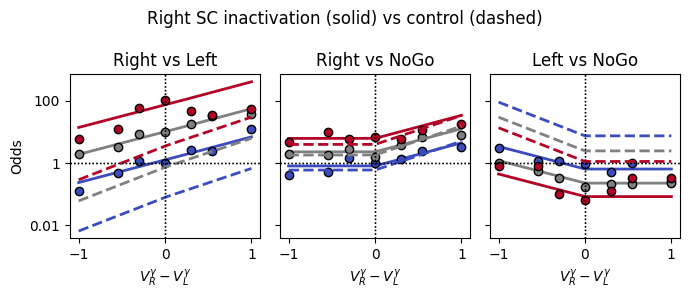

In [31]:
d = df_AV036_rightSC_inactivated

fig, axs = plt.subplots(1, 3, figsize=(7,3), sharex=True, sharey=True)
plot_3odds(model_opto, d[d.opto == 1], axs, opto=1, ls='-')                   # inactivation: fit + data
plot_3odds(model_opto, d[d.opto == 0], axs, opto=0, ls='--', show_data=False)  # control fit, dashed
fig.suptitle('Right SC inactivation (solid) vs control (dashed)')
plt.tight_layout()
plt.show()